# Khảo sát Kỹ thuật Can thiệp Augmentation Y Khoa (CLAHE & CenterCrop)\n
Notebook này được tạo ra để Minh họa trực quan và Biện luận Y khoa cho việc vì sao cần dùng Phép Cắt Tâm và Lọc Cường độ chóp nhằm cứu vớt việc nhận diện `Class 4` (SCC).

In [3]:
import os
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import albumentations as A
import kagglehub

import warnings
warnings.filterwarnings('ignore')

In [4]:
# 1. Truy xuất kho ảnh từ bộ nhớ đệm Kagglehub
try:
    path_k = kagglehub.dataset_download("mahdavi1202/skin-cancer")
    paths_dict = {}
    for root, dirs, files in os.walk(path_k):
        for f in files:
            if f.endswith('.png'):
                paths_dict[f] = os.path.join(root, f)
except Exception as e:
    print(e)
    paths_dict = {}

# Liên kết dữ liệu CSV (Dựa trên cấu trúc Thư mục PBL7 gốc)
df = pd.read_csv('../Data_handle/data/train_img_mapping.csv')

# Lọc lấy ID định danh của Nhóm Bệnh khó (Class 4 - SCC)
class4_imgs = df[df['target'] == 4]['img_id'].tolist()

def get_path(img_id):
    img_id = str(img_id)
    if not img_id.endswith('.png'): img_id += '.png'
    return paths_dict.get(img_id, None)

# Trích xuất 2 bệnh phẩm ngẫu nhiên
sample_path_4a = get_path(class4_imgs[5])
sample_path_4b = get_path(class4_imgs[10])

img_4a = cv2.cvtColor(cv2.imread(sample_path_4a), cv2.COLOR_BGR2RGB)
img_4b = cv2.cvtColor(cv2.imread(sample_path_4b), cv2.COLOR_BGR2RGB)

print("Tải bệnh phẩm hoàn tất!")

Tải bệnh phẩm hoàn tất!


In [5]:
# 2. Khai báo Kiến trúc Màng Lọc Y tế Khắc phục Nhiễu Nền
base_t = A.Compose([
    # Cắt gọn phần da thừa râu ria xung quanh
    A.CenterCrop(height=int(img_4a.shape[0]*0.8), width=int(img_4a.shape[1]*0.8), p=1.0), 
    A.Resize(224, 224),
    # Phân mảnh Histogram cường hóa vùng mờ
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0)
])

heavy_t = A.Compose([
    A.CenterCrop(height=int(img_4a.shape[0]*0.8), width=int(img_4a.shape[1]*0.8), p=1.0), 
    A.Resize(224, 224),
    A.CLAHE(clip_limit=4.0, tile_grid_size=(8, 8), p=1.0),
    # Khắc lại đường viền nham nhở của tổn thương SCC
    A.Sharpen(alpha=(0.2, 0.5), lightness=(0.5, 1.0), p=1.0)
])

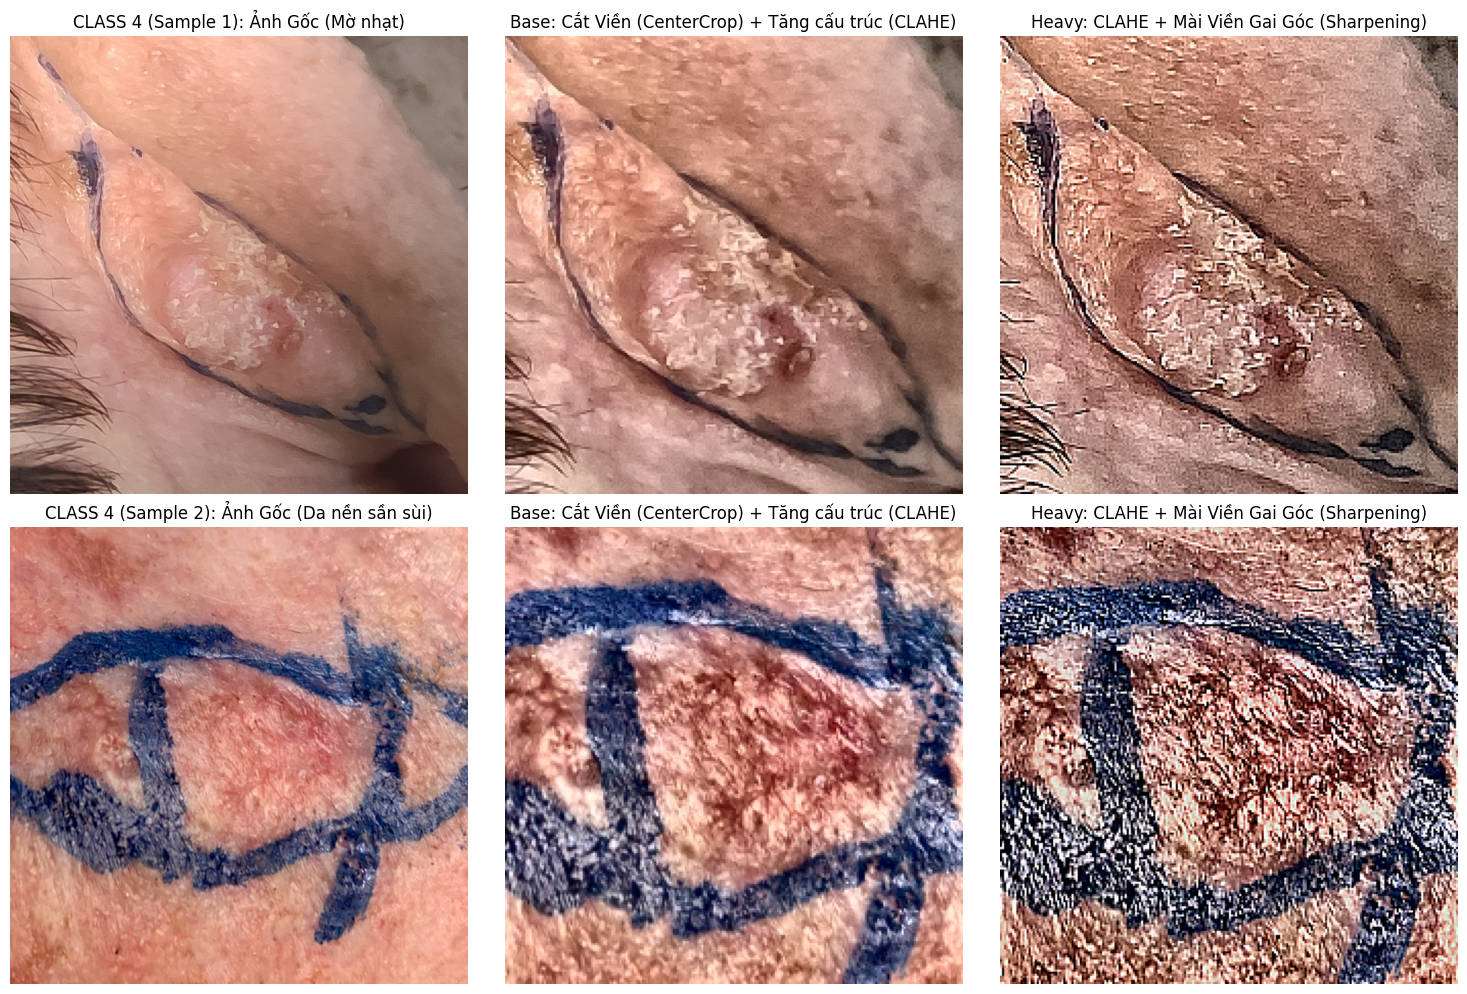

In [6]:
# 3. Ép xung Bệnh Phẩm qua Phễu lọc
aug_4a_base = base_t(image=img_4a)['image']
aug_4a_heavy = heavy_t(image=img_4a)['image']

aug_4b_base = base_t(image=img_4b)['image']
aug_4b_heavy = heavy_t(image=img_4b)['image']

# 4. Đổ dữ liệu ra Màn Hình (Matplotlib)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Bệnh phẩm A
axes[0, 0].imshow(img_4a)
axes[0, 0].set_title('CLASS 4 (Sample 1): Ảnh Gốc (Mờ nhạt)', fontsize=12)
axes[0, 1].imshow(aug_4a_base)
axes[0, 1].set_title('Base: Cắt Viền (CenterCrop) + Tăng cấu trúc (CLAHE)', fontsize=12)
axes[0, 2].imshow(aug_4a_heavy)
axes[0, 2].set_title('Heavy: CLAHE + Mài Viền Gai Góc (Sharpening)', fontsize=12)

# Bệnh phẩm B
axes[1, 0].imshow(img_4b)
axes[1, 0].set_title('CLASS 4 (Sample 2): Ảnh Gốc (Da nền sần sùi)', fontsize=12)
axes[1, 1].imshow(aug_4b_base)
axes[1, 1].set_title('Base: Cắt Viền (CenterCrop) + Tăng cấu trúc (CLAHE)', fontsize=12)
axes[1, 2].imshow(aug_4b_heavy)
axes[1, 2].set_title('Heavy: CLAHE + Mài Viền Gai Góc (Sharpening)', fontsize=12)

for ax_row in axes:
    for ax in ax_row:
        ax.axis('off')

plt.tight_layout()
plt.show()